Cloning into 'aprendizaje_profundo'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 156 (delta 78), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (156/156), 496.29 KiB | 2.77 MiB/s, done.
Resolving deltas: 100% (78/78), done.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535 (2.09 KB)

 Trainable params: 535 (2.09 KB)

 Non-trainable params: 0 (0.00 B)


Entrenamiento finalizado en la época: 209


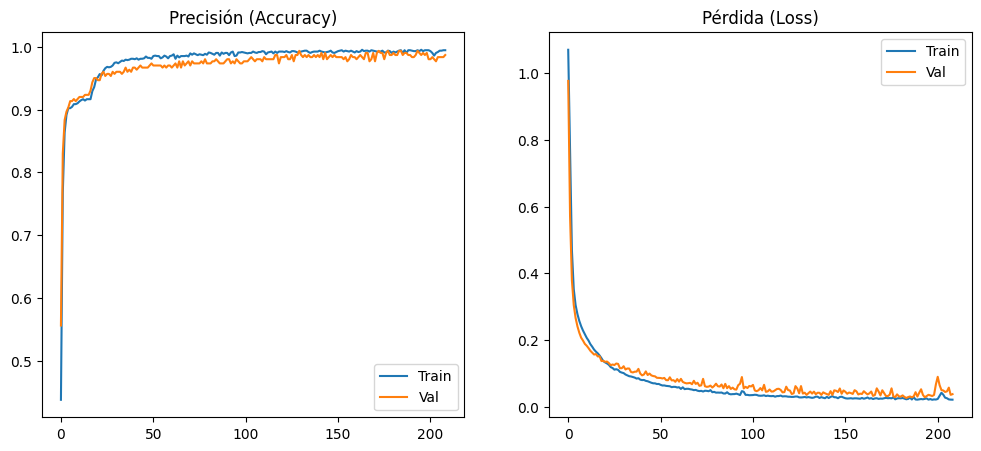

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Total Params:     535
Train Accuracy:   0.9907
Val Accuracy:     0.9933
Test Accuracy:    0.9700
F1 Macro (Test):  0.9393


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import shutil
import tensorflow as tf

if os.path.exists('aprendizaje_profundo'):
    shutil.rmtree('aprendizaje_profundo')

!git clone https://github.com/macaspe4/aprendizaje_profundo.git

from modelos.modelo_complejos3 import crear_modelo

df = pd.read_csv('wfh_burnout_dataset.csv')
features = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
            'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
            'isolation_index', 'fatigue_score']
X = df[features]
y = LabelEncoder().fit_transform(df['burnout_risk'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

model = crear_modelo(X_train_sc.shape[1])
model.summary()

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history = model.fit(X_train_sc, y_train,
                    validation_data=(X_val_sc, y_val),
                    epochs=300,
                    callbacks=[callback],
                    verbose=0)

print(f"\nEntrenamiento finalizado en la época: {len(history.history['loss'])}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Precisión (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Pérdida (Loss)')
plt.legend()
plt.show()

y_train_pred = np.argmax(model.predict(X_train_sc), axis=1)
y_val_pred = np.argmax(model.predict(X_val_sc), axis=1)
y_test_pred = np.argmax(model.predict(X_test_sc), axis=1)


print(f"Total Params:     {model.count_params()}")
print(f"Train Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Val Accuracy:     {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Macro (Test):  {f1_score(y_test, y_test_pred, average='macro'):.4f}")


### Conclusión
Este tercer modelo utiliza una arquitectura más profunda pero con menos neuronas (4 capas ocultas), lo que reduce bastante su tamaño hasta 535 parámetros. Aun siendo un modelo mucho más ligero, consigue resultados muy buenos: 99,07% de precisión en entrenamiento y 97,00% en test.

Además, se utilizó Early Stopping, que paró el entrenamiento en la época 209 cuando el modelo ya había alcanzado su mejor rendimiento en validación (99,33%), evitando seguir entrenando innecesariamente.

El F1 Macro de 0,9393 indica que el modelo clasifica bien las tres categorías de riesgo de burnout. En general, este modelo demuestra que una red más profunda pero con menos parámetros puede seguir siendo muy precisa, logrando buenos resultados con un coste computacional más bajo